In [12]:
import torch
from pathlib import Path
import sys

# 루트 경로 추가 (Model, dataset 로딩 위해)
root_dir = Path('/storage/personal/eungyeop/LLM/tabular/ProtoLLM')
sys.path.append(str(root_dir))

from models.TabularFLM_S import Model
from dataset.data_dataloaders import prepare_embedding_dataloaders
from utils.util import fix_seed
from ot.batch import solve_gromov_batch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

ckpt_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/Heart_disease_statlog+Cardiovascular_Disease_Dataset+heart_target_3+heart_target_4/Pre/ngraphs-8_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_fgw_alpha-1_vq_beta-0.3_kl_gamma-2.0_target_data-heart_description-graddetach5_joint_lrdown/42/best_vanilla.pt"

# checkpoint load
ckpt = torch.load(ckpt_path, map_location=device)
args = ckpt['args']

# 모델 초기화
model = Model(
    args,
    args.input_dim,
    args.hidden_dim,
    args.output_dim,
    args.dropout_rate,
    args.llm_model,
    experiment_id="viz",
    mode="viz"
).to(device)

sd = ckpt['model_state_dict']
missing, unexpected = model.load_state_dict(sd, strict=False)
print("Missing keys:", missing)
print("Unexpected keys:", unexpected)

model.eval()


Missing keys: []
Unexpected keys: []


Model(
  (latent_graph): LatentCompositeGraph(
    (q_proj): Linear(in_features=768, out_features=64, bias=True)
    (k_proj): Linear(in_features=768, out_features=64, bias=True)
  )
  (graph_quantizer): GraphQuantizer()
  (gnn_experts): LatentCompositeGNN(
    (graph_gnns): ModuleList(
      (0-7): 8 x lightGraphNeuralNet(
        (dropout): Dropout(p=0.1, inplace=False)
        (linear): Linear(in_features=768, out_features=192, bias=True)
        (update): Linear(in_features=192, out_features=768, bias=True)
        (norm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      )
    )
    (readouts): ModuleList(
      (0-7): 8 x GraphReadout(
        (proj): Sequential(
          (0): Linear(in_features=768, out_features=192, bias=True)
          (1): ReLU()
          (2): Dropout(p=0.1, inplace=False)
          (3): Linear(in_features=192, out_features=768, bias=True)
        )
        (norm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      )
    )
  )
  (basis_la

In [3]:
args2 = args
fix_seed(args2.random_seed)

# source_data가 리스트일 경우 여러 개
sources = args2.source_data if isinstance(args2.source_data, (list, tuple)) else [args2.source_data]

loaders = {}
for src in sources:
    print(f"Loading dataloader for source: {src}")
    res = prepare_embedding_dataloaders(args2, src)
    tr, va, te = res['loaders']
    
    from torch.utils.data import ConcatDataset, DataLoader
    ds = ConcatDataset([tr.dataset, va.dataset, te.dataset])
    
    loaders[src] = DataLoader(ds, batch_size=32, shuffle=False)


Loading dataloader for source: Heart_disease_statlog
Loading embeddings from: /storage/personal/eungyeop/dataset/embedding/tabular_embeddings_carte/gpt2_mean/embedding_Heart_disease_statlog.pkl
Training data size: 162
Validation data size: 54
Test data size: 54
Loading dataloader for source: Cardiovascular_Disease_Dataset
Loading embeddings from: /storage/personal/eungyeop/dataset/embedding/tabular_embeddings_carte/gpt2_mean/embedding_Cardiovascular_Disease_Dataset.pkl
Training data size: 600
Validation data size: 200
Test data size: 200
Loading dataloader for source: heart_target_3
Loading embeddings from: /storage/personal/eungyeop/dataset/embedding/tabular_embeddings_carte/gpt2_mean/embedding_heart_target_3.pkl
Training data size: 600
Validation data size: 200
Test data size: 200
Loading dataloader for source: heart_target_4
Loading embeddings from: /storage/personal/eungyeop/dataset/embedding/tabular_embeddings_carte/gpt2_mean/embedding_heart_target_4.pkl
Training data size: 600
Va

In [4]:
import torch.nn.functional as F

@torch.no_grad()
def extract_basis_attention_and_embedding(model, batch):
    batch = {k: (v.to(device) if isinstance(v, torch.Tensor) else v) for k, v in batch.items()}

    # desc/name/value gather
    desc_embeddings, name_embeddings, value_embeddings = [], [], []
    if all(k in batch for k in ['cat_name_embeddings', 'cat_value_embeddings', 'cat_desc_embeddings']):
        desc_embeddings.append(batch['cat_desc_embeddings'])
        name_embeddings.append(batch['cat_name_embeddings'])
        value_embeddings.append(batch['cat_value_embeddings'])
    if all(k in batch for k in ['num_prompt_embeddings', 'num_desc_embeddings']):
        desc_embeddings.append(batch['num_desc_embeddings'])
        name_embeddings.append(batch['num_name_embeddings'])
        value_embeddings.append(batch['num_prompt_embeddings'])

    desc = torch.cat(desc_embeddings, dim=1)
    name = torch.cat(name_embeddings, dim=1)
    value = torch.cat(value_embeddings, dim=1)

    # CLS + value token concat
    x_basis = torch.cat([model.basis_cls.expand(value.size(0), 1, model.input_dim), value], dim=1)

    attentions = []

    # each BasisGAT layer
    for l in range(model.num_basis_layers):
        norm_x = model.basis_layer_norms[l](x_basis)
        basis_outputs, att = model.basis_layers[l](name, norm_x)
        
        # attention shape: [B, H, T, T]
        attentions.append(att[0].detach().cpu().numpy())
        
        x_basis = x_basis + basis_outputs.reshape(x_basis.size(0), x_basis.size(1), model.input_dim)

    embeddings = x_basis[0].detach().cpu().numpy()  # CLS+tokens, shape [T, D]
    return attentions, embeddings


In [5]:
import matplotlib.pyplot as plt
import numpy as np
import os
def plot_attention_heatmap(att, feature_names, title):
    H, T, _ = att.shape
    # ---- Bigger, readable figure ----
    figsize_x = max(8, T * 0.8)  # at least width 8
    figsize_y = max(4, H * 3)    # at least height 4

    plt.figure(figsize=(figsize_x, figsize_y))

    for h in range(H):
        plt.subplot(1, H, h+1)
        plt.imshow(att[h], cmap='viridis')

        plt.xticks(range(T), feature_names, rotation=90, fontsize=10)
        plt.yticks(range(T), feature_names, fontsize=10)

        plt.title(f"{title} - Head {h}", fontsize=14)
        plt.colorbar()

    plt.tight_layout()
    plt.show()
from sklearn.manifold import TSNE

def plot_embedding_tsne(emb):
    # emb: [T, D]
    tsne = TSNE(n_components=2, perplexity=10, learning_rate=100)
    xy = tsne.fit_transform(emb)

    plt.figure(figsize=(6, 6))
    plt.scatter(xy[:, 0], xy[:, 1])
    for i in range(xy.shape[0]):
        plt.text(xy[i,0], xy[i,1], str(i), fontsize=8)
    plt.title("t-SNE of embeddings (CLS + features)")
    plt.show()

# ---- viz utilities ----
def set_attention_save_dir( experiment_id, mode):
    base_viz_dir = f"/storage/personal/eungyeop/experiments/visualization/{args.llm_model}/{args.source_data}/{mode}/{experiment_id}"
    attention_save_dir = os.path.join(base_viz_dir, 'attention_maps')
    os.makedirs(attention_save_dir, exist_ok=True)

def extract_feature_names( batch):
    names = []
    if 'cat_desc_texts' in batch:
        for t in batch['cat_desc_texts']:
            names.append(str(t[0] if isinstance(t, tuple) else t).split(",")[0].split("'")[0])
    if 'num_desc_texts' in batch:
        for t in batch['num_desc_texts']:
            names.append(str(t[0] if isinstance(t, tuple) else t).split(",")[0].split("'")[0])
    uniq = []
    seen = set()
    for n in names:
        if n not in seen:
            seen.add(n); uniq.append(n)
    return uniq

def save_attention_maps_to_file( attention_weights, batch, labels=None, sample_ids=None):
    if attention_save_dir is None:
        return
    node_names = ["CLS"] + extract_feature_names(batch)
    for layer_idx, layer_attention in enumerate(attention_weights):
        B = layer_attention.shape[0]
        for b in range(B):
            att = layer_attention[b].mean(dim=0).detach().cpu().numpy()
            sid = sample_ids[b] if sample_ids is not None else attention_counter
            lab = labels[b].item() if labels is not None else "unknown"
            np.savez(os.path.join(attention_save_dir, f"layer_{layer_idx}_sample_{sid}_label_{lab}.npz"),
                        attention_map=att, feature_names=np.array(node_names),
                        layer_idx=layer_idx, sample_id=sid, label=lab)
            attention_counter += 1

import numpy as np

def summarize_embedding_stats(emb, feature_names):
    """
    emb: numpy array [T, D]
    feature_names: list of T names ("CLS" + variable names)
    """
    T, D = emb.shape
    
    print("=== Embedding statistics per token (CLS + features) ===")
    stats = {}
    
    for i in range(T):
        vec = emb[i]
        mean = vec.mean()
        std = vec.std()
        
        stats[feature_names[i]] = {
            'mean': float(mean),
            'std': float(std)
        }
        print(f"{feature_names[i]:>15}  | mean={mean:.4f} | std={std:.4f}")
    
    # 전체 embedding 분포 요약
    print("\n=== Global embedding statistics ===")
    print(f"global mean: {emb.mean():.4f}")
    print(f"global std : {emb.std():.4f}")
    
    return stats

import matplotlib.pyplot as plt
import numpy as np

def plot_attention_with_inverse(
    att,
    feature_names,
    title="Attention",
    value_fontsize=6,
    tick_fontsize=8,
    title_fontsize=12,
    figsize_scale=1.0,
):
    H, T, _ = att.shape

    figsize_x = max(10, T * 0.7) * figsize_scale
    figsize_y = max(5, H * 3) * figsize_scale

    fig, axes = plt.subplots(H, 2, figsize=(figsize_x, figsize_y))
    if H == 1:
        axes = np.expand_dims(axes, 0)

    cmap = "viridis"

    for h in range(H):
        # ---- LEFT: Attention ----
        left_vmin = att[h].min()
        left_vmax = att[h].max()

        ax = axes[h, 0]
        im = ax.imshow(att[h], cmap=cmap, vmin=left_vmin, vmax=left_vmax)
        ax.set_title(f"{title} - Head {h}", fontsize=title_fontsize)

        ax.set_xticks(range(T))
        ax.set_yticks(range(T))
        ax.set_xticklabels(feature_names, rotation=90, fontsize=tick_fontsize)
        ax.set_yticklabels(feature_names, fontsize=tick_fontsize)

        for i in range(T):
            for j in range(T):
                ax.text(j, i, f"{att[h, i, j]:.2f}",
                        ha="center", va="center",
                        fontsize=value_fontsize,
                        color="white" if att[h, i, j] > (left_vmin+left_vmax)/2 else "black")

        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02)

        # ---- RIGHT: (1 - Attention) ----
        inv = 1 - att[h]
        right_vmin = inv.min()
        right_vmax = inv.max()

        ax2 = axes[h, 1]
        im2 = ax2.imshow(inv, cmap=cmap, vmin=right_vmin, vmax=right_vmax)
        ax2.set_title(f"(1 - Attention) - Head {h}", fontsize=title_fontsize)

        ax2.set_xticks(range(T))
        ax2.set_yticks(range(T))
        ax2.set_xticklabels(feature_names, rotation=90, fontsize=tick_fontsize)
        ax2.set_yticklabels(feature_names, fontsize=tick_fontsize)

        for i in range(T):
            for j in range(T):
                ax2.text(j, i, f"{inv[i, j]:.2f}",
                         ha="center", va="center",
                         fontsize=value_fontsize,
                         color="white" if inv[i, j] > (right_vmin+right_vmax)/2 else "black")

        fig.colorbar(im2, ax=ax2, fraction=0.046, pad=0.02)

    plt.tight_layout()
    plt.show()





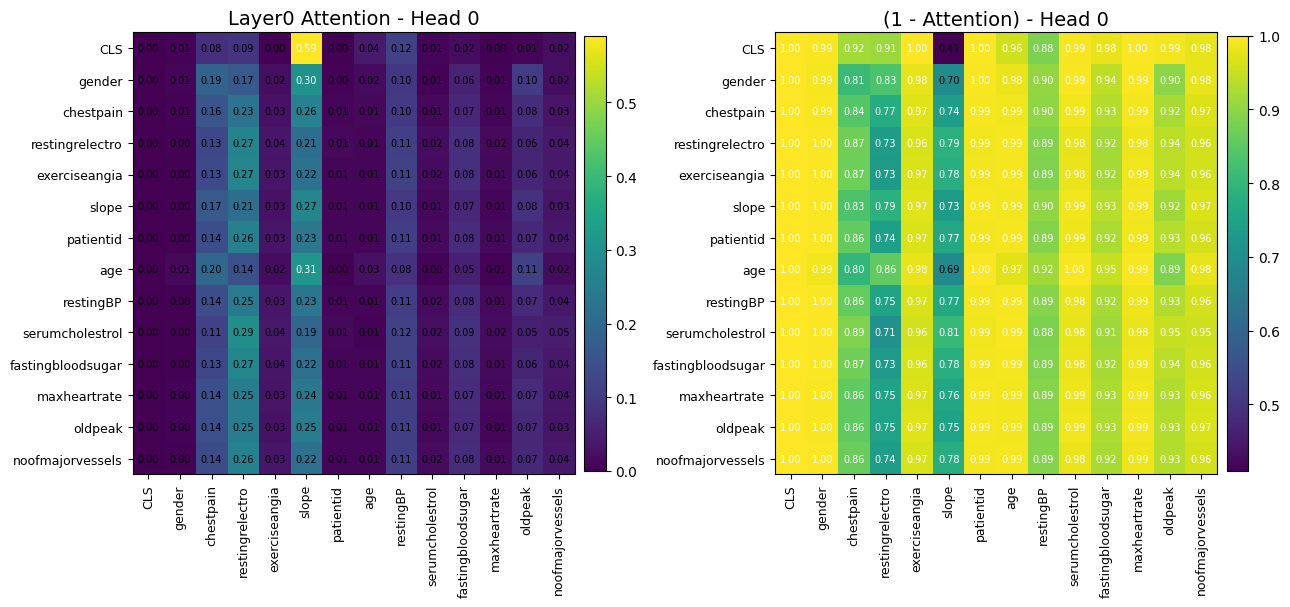

=== Embedding statistics per token (CLS + features) ===
            CLS  | mean=-0.0285 | std=0.2829
         gender  | mean=0.0140 | std=2.3778
      chestpain  | mean=0.2346 | std=5.5411
restingrelectro  | mean=0.2869 | std=6.4791
  exerciseangia  | mean=0.0254 | std=2.4438
          slope  | mean=0.2223 | std=5.6060
      patientid  | mean=0.2368 | std=6.9917
            age  | mean=-0.0833 | std=2.8170
      restingBP  | mean=0.2392 | std=6.2144
serumcholestrol  | mean=-0.1003 | std=1.4847
fastingbloodsugar  | mean=-0.2075 | std=3.8094
   maxheartrate  | mean=0.1686 | std=4.1450
        oldpeak  | mean=0.1404 | std=4.0140
noofmajorvessels  | mean=0.2141 | std=4.9220

=== Global embedding statistics ===
global mean: 0.0973
global std : 4.5183


In [6]:
src = sources[1]   # 첫 source
loader = loaders[src]

batch = next(iter(loader))

atts, emb = extract_basis_attention_and_embedding(model, batch)

# feature names 가져오기
var_names = extract_feature_names(batch)
feature_names = ["CLS"] + var_names

# 첫 layer attention 시각화
#plot_attention_heatmap(atts[0], feature_names, "Layer0 Attention")
plot_attention_with_inverse(
    att=atts[0],
    feature_names=feature_names,
    title="Layer0 Attention",
    value_fontsize=7,
    tick_fontsize=9,
    title_fontsize=14,
    figsize_scale=1.3,
)
stats = summarize_embedding_stats(emb, feature_names)




========== Simulating LCG Initialization Strategies ==========
>> 1. Collecting CLS tokens from Vanilla GAT...
   >> Total CLS Collected: 3270
>> Simulating Strategy: [HIERARCHICAL]...


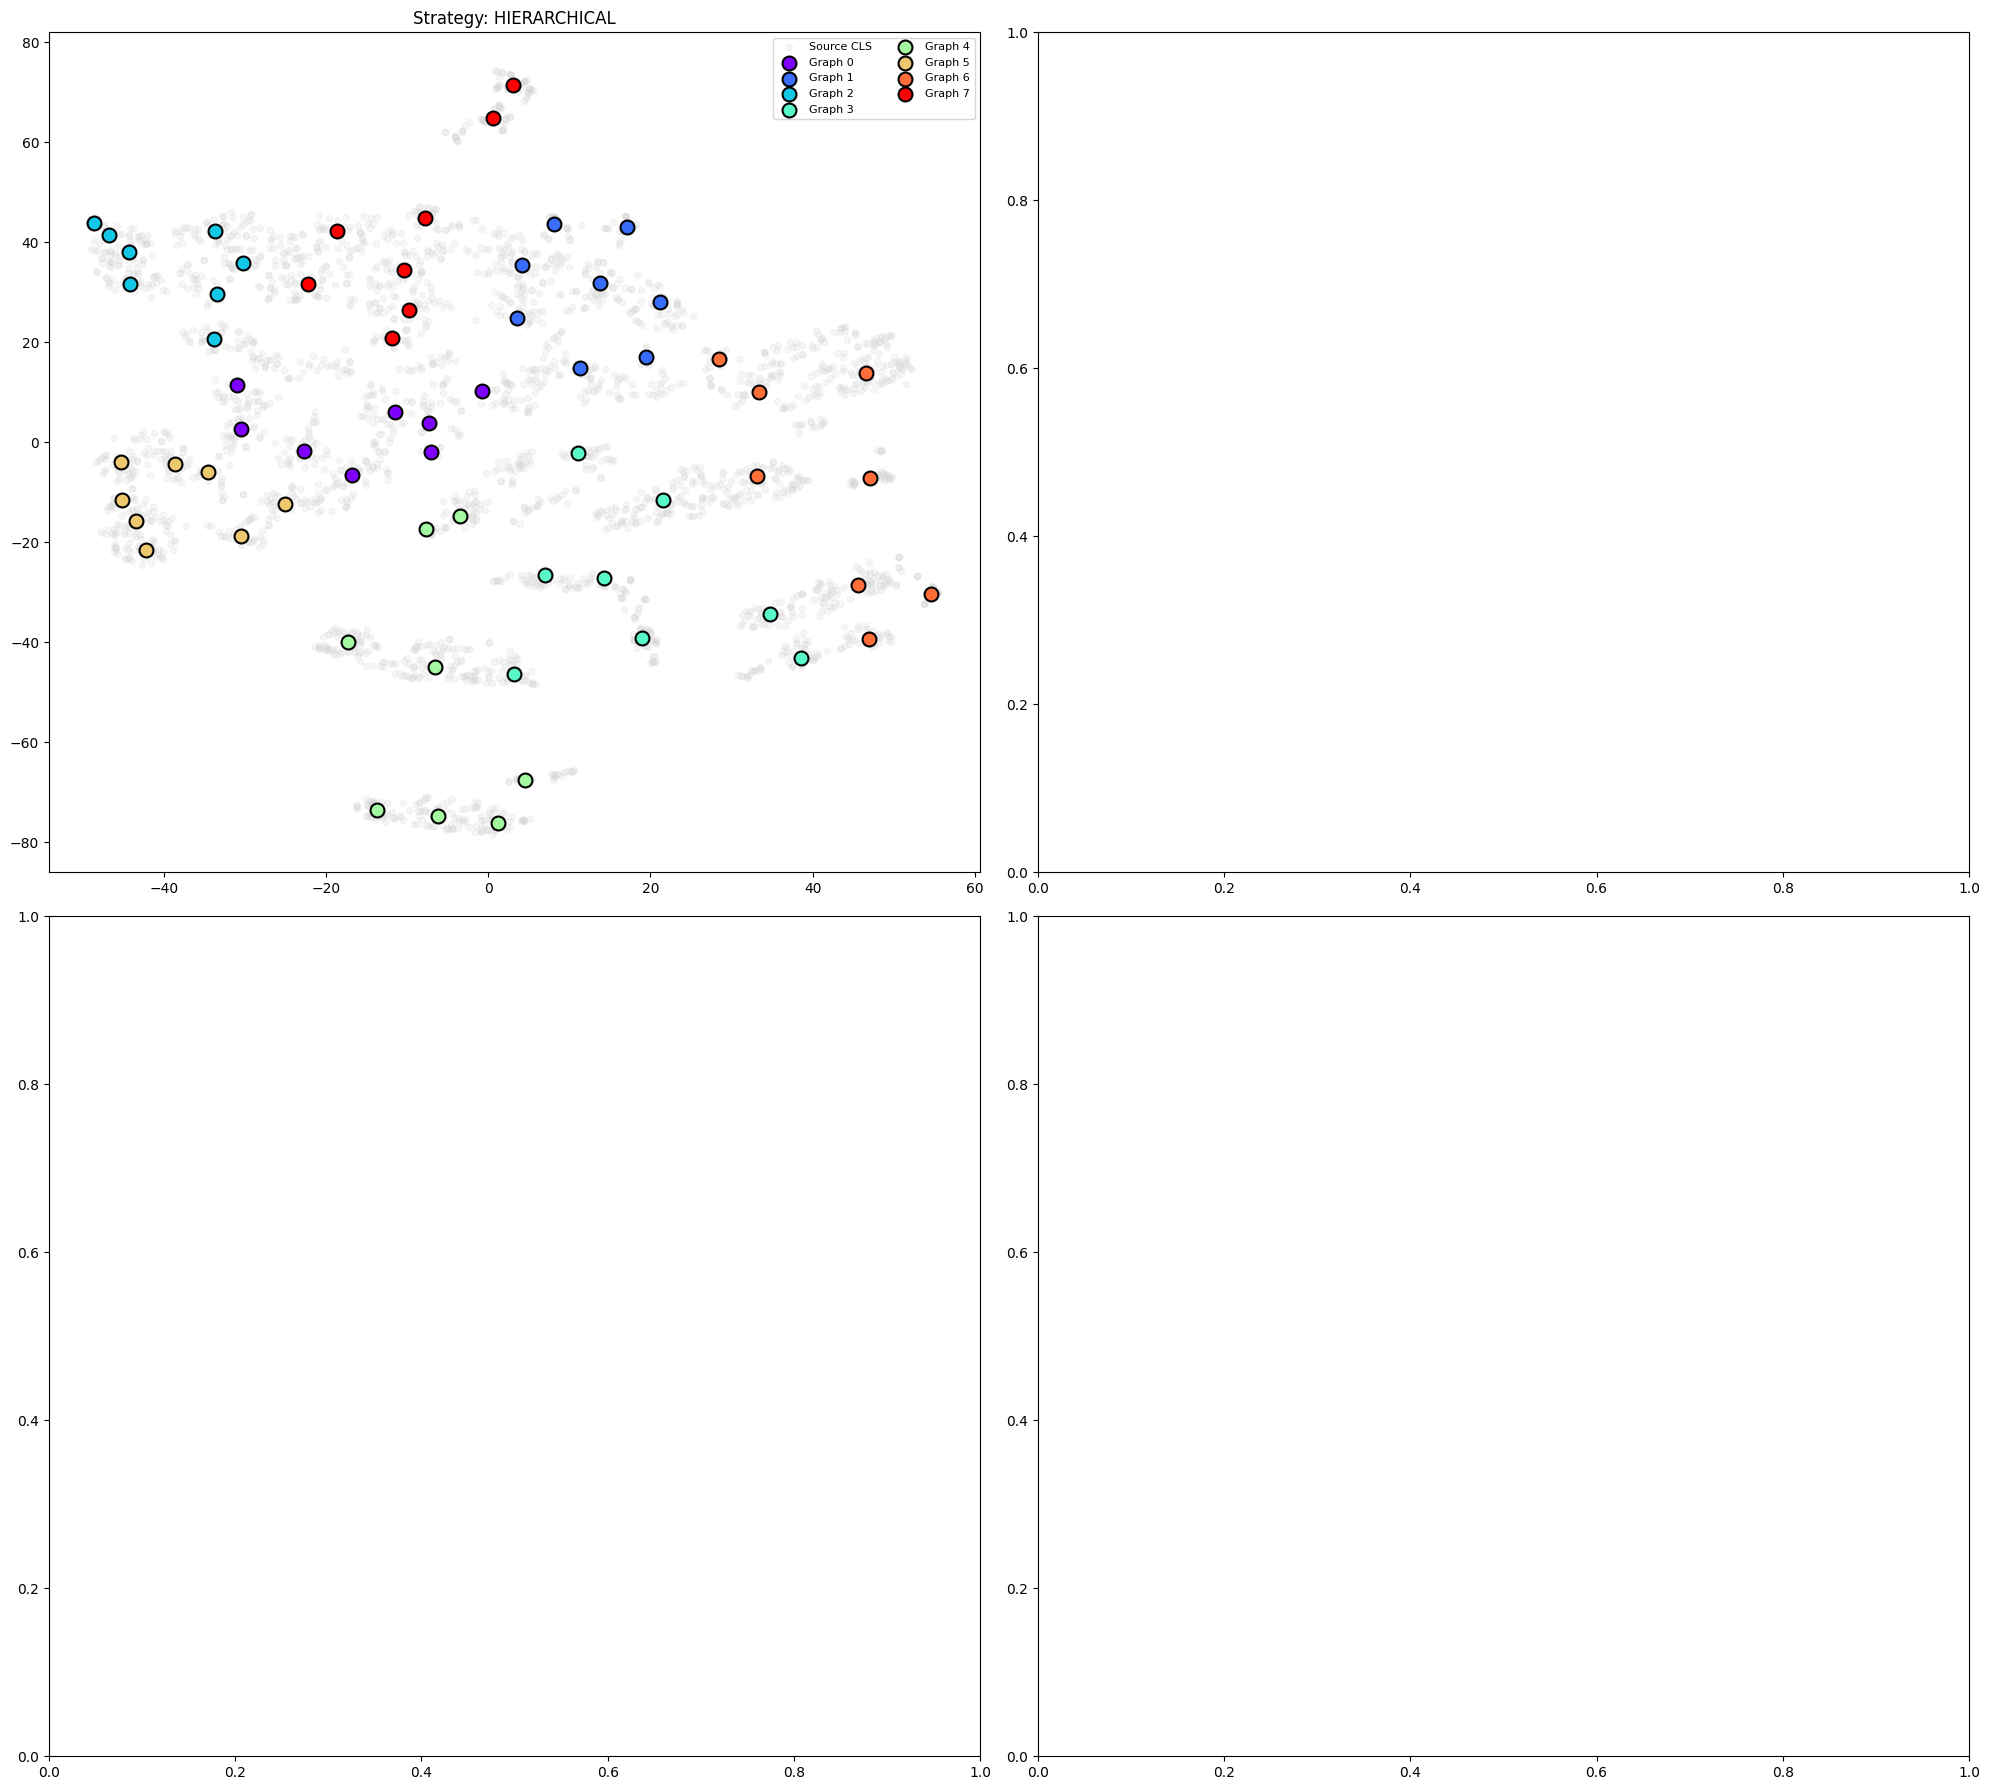

In [7]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE

def simulate_and_visualize_strategies(model, loaders, device, M=8, K=8, num_vis_samples=3000):
    print(f"\n{'='*10} Simulating LCG Initialization Strategies {'='*10}")
    
    # --- Step 1. Collect Pre-trained CLS Tokens ---
    print(">> 1. Collecting CLS tokens from Vanilla GAT...")
    all_cls = []
    model.eval()
    
    with torch.no_grad():
        for src_name, loader in loaders.items():
            for batch in loader:
                batch = {k: (v.to(device) if isinstance(v, torch.Tensor) else v) for k, v in batch.items()}
                
                # GAT Forward Logic (CLS Extraction)
                name_embs, val_embs = [], []
                if 'cat_name_embeddings' in batch: name_embs.append(batch['cat_name_embeddings'])
                if 'num_name_embeddings' in batch: name_embs.append(batch['num_name_embeddings'])
                if 'cat_value_embeddings' in batch: val_embs.append(batch['cat_value_embeddings'])
                if 'num_prompt_embeddings' in batch: val_embs.append(batch['num_prompt_embeddings'])
                
                if not name_embs: continue
                name = torch.cat(name_embs, dim=1)
                val = torch.cat(val_embs, dim=1)
                
                x_basis = torch.cat([model.basis_cls.expand(val.size(0), 1, model.input_dim), val], dim=1)
                for l in range(model.num_basis_layers):
                    norm_x = model.basis_layer_norms[l](x_basis)
                    basis_outputs, _ = model.basis_layers[l](name, norm_x)
                    x_basis = x_basis + basis_outputs.reshape(x_basis.size(0), x_basis.size(1), model.input_dim)
                
                # CLS Token (Index 0)
                cls_token = x_basis[:, 0, :].cpu().numpy()
                all_cls.append(cls_token)
                
                # 너무 많으면 메모리 터지니 2만개 정도만 수집
                if sum([len(x) for x in all_cls]) > 20000: break
    
    pool_cls = np.concatenate(all_cls, axis=0)
    print(f"   >> Total CLS Collected: {pool_cls.shape[0]}")

    # --- Step 2. Define Strategies ---
    strategies = ['hierarchical']
    
    # 시각화용 Figure 생성 (2x2 Grid)
    fig, axes = plt.subplots(2, 2, figsize=(20, 18))
    axes = axes.flatten()
    
    # t-SNE를 위한 배경 데이터 샘플링 (속도 최적화)
    if pool_cls.shape[0] > num_vis_samples:
        idx = np.random.choice(pool_cls.shape[0], num_vis_samples, replace=False)
        vis_cls = pool_cls[idx]
    else:
        vis_cls = pool_cls

    for i, strategy in enumerate(strategies):
        print(f">> Simulating Strategy: [{strategy.upper()}]...")
        
        # --- Logic per Strategy ---
        centroids = None # Shape: [M, K, D]
        
        if strategy in ['sequential', 'round_robin', 'density']:
            # Global KMeans
            kmeans = KMeans(n_clusters=M*K, n_init=10, random_state=42).fit(pool_cls)
            centers = kmeans.cluster_centers_
            
            if strategy == 'sequential':
                # [M*K, D] -> [M, K, D]
                centroids = centers.reshape(M, K, -1)
                
            elif strategy == 'round_robin':
                # [M*K, D] -> [K, M, D] -> Transpose -> [M, K, D]
                centroids = centers.reshape(K, M, -1).transpose(1, 0, 2)
                
            elif strategy == 'density':
                # Sort by cluster size
                labels = kmeans.labels_
                counts = np.bincount(labels, minlength=M*K)
                sorted_idx = np.argsort(counts)[::-1] # Descending
                centroids = centers[sorted_idx].reshape(M, K, -1)
                
        elif strategy == 'hierarchical':
            # 2-Step KMeans
            centroids = np.zeros((M, K, pool_cls.shape[1]))
            km_global = KMeans(n_clusters=M, n_init=10, random_state=42).fit(pool_cls)
            
            for m in range(M):
                group = pool_cls[km_global.labels_ == m]
                # 데이터 부족 시 보충
                if len(group) < K:
                    supp = pool_cls[np.random.choice(len(pool_cls), K - len(group))]
                    group = np.concatenate([group, supp], axis=0)
                    
                km_local = KMeans(n_clusters=K, n_init=10, random_state=42).fit(group)
                centroids[m] = km_local.cluster_centers_

        # --- Step 3. t-SNE & Plotting ---
        # [CLS + Centroids]를 합쳐서 t-SNE 수행
        flat_centroids = centroids.reshape(-1, centroids.shape[-1])
        all_data = np.concatenate([vis_cls, flat_centroids], axis=0)
        
        # t-SNE (Perplexity 낮춤 for sparse centroids)
        tsne = TSNE(n_components=2, perplexity=30, init='pca', learning_rate='auto', random_state=42)
        embedded = tsne.fit_transform(all_data)
        
        idx_split = vis_cls.shape[0]
        emb_cls = embedded[:idx_split]
        emb_cen = embedded[idx_split:]
        
        # Plot
        ax = axes[i]
        # 배경 (Source CLS)
        ax.scatter(emb_cls[:, 0], emb_cls[:, 1], c='lightgray', alpha=0.2, s=20, label='Source CLS')
        
        # Centroids (Color by Graph ID)
        colors = cm.rainbow(np.linspace(0, 1, M))
        for m in range(M):
            start = m * K
            end = (m + 1) * K
            subset = emb_cen[start:end]
            ax.scatter(subset[:, 0], subset[:, 1], color=colors[m], marker='o', s=100, 
                       edgecolor='black', linewidth=1.5, label=f'Graph {m}' if i==0 else "")
            
        ax.set_title(f"Strategy: {strategy.upper()}")
        if i == 0: ax.legend(loc='best', ncol=2, fontsize=8)

    plt.tight_layout()
    plt.show()

# 실행
simulate_and_visualize_strategies(model, loaders, device, M=8, K=8)

## Gradient Check

In [1]:
import sys
import os
import time
import logging
import shutil
import numpy as np
import pandas as pd
from pathlib import Path
import math
import copy
import pickle
import random
import warnings
from collections import Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.nn.init as nn_init
import torch.optim as optim
from torch import Tensor
from torch.utils.data import DataLoader, ConcatDataset

# Sklearn
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score, precision_recall_curve
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import train_test_split
from sklearn.manifold import TSNE

# Visualization
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

# System Path (사용자 환경)
root_dir = Path('/storage/personal/eungyeop/LLM/tabular/ProtoLLM')
if str(root_dir) not in sys.path:
    sys.path.append(str(root_dir))

# Custom Modules
from models.TabularFLM_S import Model
from models.coordinate import CoordinatorMLP 
from models.LCG import LatentCompositeGraph, GraphQuantizer 
from models.LCGGNN import LatentCompositeGNN
from models.BasisGraphAttention import BasisGATLayer_MUL, BasisGATLayer_IND
from utils.util import fix_seed, make_warmup_cosine_epochs, format_time

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f">>> Device: {device}")

# =============================================================================
# [User Provided] Data Loading Functions
# =============================================================================
def prepare_embedding_dataloaders(args, dataset_name):
    """저장된 embedding 데이터를 로드하고 train/val/test로 분할한 뒤 DataLoader로 변환"""
    
    torch.manual_seed(args.random_seed)
    np.random.seed(args.random_seed)
    random.seed(args.random_seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(args.random_seed)
        torch.cuda.manual_seed_all(args.random_seed)
    torch.backends.cudnn.benchmark = True
    
    # 파일 경로 설정
    base_path = "/storage/personal/eungyeop/dataset/embedding"
    if args.embed_type == "_":
        sub_dir = f"tabular_embeddings_/{args.llm_model}"
    else:
        sub_dir = f"tabular_embeddings_{args.embed_type}/{args.llm_model}"
    emb_name =  f"embedding_{dataset_name}.pkl"
    file_path = os.path.join(base_path, sub_dir, emb_name)
    
    print(f"Loading embeddings from: {file_path}")
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"File not found: {file_path}")
    
    # 데이터 로드
    with open(file_path, 'rb') as f:
        data = pickle.load(f)
    
    embeddings = data['embeddings']
    labels = [emb['y'].item() for emb in embeddings]
    num_classes = data['num_classes']
    
    if dataset_name == "heart_disease_clean":
        print("Using custom sampling : 100 random samples (60/20/20 split)")
        total_indices = np.arange(len(embeddings))
        np.random.shuffle(total_indices)
        selected_indices = total_indices[:100]
        embeddings = [embeddings[i] for i in selected_indices]
        labels = [labels[i] for i in selected_indices]
        
    # Train/Val/Test Split (60/20/20)
    indices = list(range(len(embeddings)))
    train_val_idx, test_idx = train_test_split(
        indices, test_size=0.2,
        stratify=labels,
        random_state=args.random_seed
    )
    
    train_val_embeddings = [embeddings[i] for i in train_val_idx]
    train_val_labels = [labels[i] for i in train_val_idx]
    
    train_idx, val_idx = train_test_split(
        list(range(len(train_val_embeddings))),
        test_size=0.25,
        stratify=train_val_labels,
        random_state=args.random_seed
    )
    
    # Split datasets
    train_dataset = [train_val_embeddings[i] for i in train_idx]
    val_dataset = [train_val_embeddings[i] for i in val_idx]
    test_dataset = [embeddings[i] for i in test_idx]
    
    # DataLoader 생성
    train_loader = DataLoader(train_dataset, batch_size=args.batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=args.batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=args.batch_size, shuffle=False)
    
    print(f"Training data size: {len(train_dataset)}")
    print(f"Validation data size: {len(val_dataset)}")
    print(f"Test data size: {len(test_dataset)}")
    
    return {
        'loaders': (train_loader, val_loader, test_loader),
        'num_classes': num_classes
    }

def get_few_shot_embedding_samples(train_loader, args):
   """train_loader에서 embedding data의 few-shot 샘플링을 수행 (표준 K-shot)"""
   np.random.seed(args.random_seed)
   dataset = train_loader.dataset
   labels = [data['y'].item() for data in dataset]
   num_classes = len(set(labels))
   
   shot_per_class = args.few_shot 
   
   support_data = []
   for cls in range(num_classes):
       cls_data = [data for data in dataset if data['y'].item() == cls]
       if len(cls_data) < shot_per_class:
           warnings.warn(f"Class {cls} has fewer samples ({len(cls_data)}) than required ({shot_per_class}). Using replacement sampling.")
           selected = random.choices(cls_data, k=shot_per_class)
       else:
           selected = random.sample(cls_data, k=shot_per_class)
       support_data.extend(selected)
   
   return DataLoader(support_data, batch_size=args.batch_size, shuffle=True)

>>> Device: cuda


In [4]:
# =============================================================================
# 2-1. [Robust Training Functions] 데이터셋 길이에 의존하지 않는 안전한 학습 함수
# =============================================================================
def binary_train(model, train_loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    total_samples = 0
    for batch in train_loader:
        optimizer.zero_grad()
        if isinstance(batch, dict):
            y = batch['y'].to(device)
            loss = model(batch, y) # Forward returns loss
        else:
            x, y = batch; x, y = x.to(device), y.to(device)
            output = model(x)
            loss = criterion(output, y.float())
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(batch['y']) if isinstance(batch, dict) else loss.item() * len(y)
        total_samples += len(batch['y']) if isinstance(batch, dict) else len(y)
    return total_loss / max(total_samples, 1)

def multi_train(model, train_loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    total_samples = 0
    for batch in train_loader:
        optimizer.zero_grad()
        if isinstance(batch, dict):
            y = batch['y'].to(device).long()
            loss = model(batch, y)
        else:
            x, y = batch; x, y = x.to(device), y.to(device)
            output = model(x)
            loss = criterion(output, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(batch['y']) if isinstance(batch, dict) else loss.item() * len(y)
        total_samples += len(batch['y']) if isinstance(batch, dict) else len(y)
    return total_loss / max(total_samples, 1)

def binary_evaluate(model, loader, criterion, device):
    model.eval()
    loss_g_sum, loss_l_sum, dataset_len = 0.0, 0.0, 0
    y_true, y_pred_g, y_pred_l = [], [], []
    has_global = False
    
    with torch.no_grad():
        for batch in loader:
            preds = model.predict(batch, return_all=True)
            target = batch['y'].to(device).view(-1, 1).float()
            
            if isinstance(preds, tuple) and len(preds) == 2:
                global_pred, local_pred = preds
                has_global = True
                loss_g = criterion(global_pred, target)
                loss_g_sum += loss_g.item() * len(target)
                y_pred_g.extend(torch.sigmoid(global_pred).cpu().numpy())
            else:
                local_pred = preds
            
            loss_l = criterion(local_pred, target)
            loss_l_sum += loss_l.item() * len(target)
            y_pred_l.extend(torch.sigmoid(local_pred).cpu().numpy())
            y_true.extend(target.cpu().numpy())
            dataset_len += len(target)
            
    loss_l_avg = loss_l_sum / max(dataset_len, 1)
    res_l = (loss_l_avg, np.array(y_true), np.array(y_pred_l))
    
    if has_global:
        loss_g_avg = loss_g_sum / max(dataset_len, 1)
        res_g = (loss_g_avg, np.array(y_true), np.array(y_pred_g))
    else:
        res_g = res_l
    return res_g, res_l

def multi_evaluate(model, loader, criterion, device):
    # (Multi-class도 유사하게 구현 필요, Binary가 메인이므로 생략하거나 필요시 추가)
    # 현재 코드에서는 Binary 가정하고 진행
    return binary_evaluate(model, loader, criterion, device)

# =============================================================================
# 2-2. [Step Loader]
# =============================================================================
class MultiSourceStepLoader:
    def __init__(self, loaders, mode='random', seed=42, src_idx=None):
        self.loaders = loaders
        self.mode = mode
        self.rng = np.random.default_rng(seed)
        self.src_idx = src_idx
        self._blens = [len(dl) for dl in loaders]
        self._steps = int(np.sum(self._blens))

    def __len__(self): return self._steps
    def __iter__(self):
        iters = [iter(dl) for dl in self.loaders]
        pos = [0] * len(self.loaders)
        k = len(self.loaders)
        for s in range(self._steps):
            idx = s % k if self.mode == 'round' else int(self.rng.integers(0, k))
            if pos[idx] >= self._blens[idx]:
                iters[idx] = iter(self.loaders[idx]); pos[idx] = 0
            batch = next(iters[idx]); pos[idx] += 1
            batch['src_idx'] = self.src_idx if self.src_idx is not None else idx
            yield batch

def make_step(loaders, mode='random', seed=42): return MultiSourceStepLoader(loaders, mode=mode, seed=seed)

# =============================================================================
# 2-3. [Viz Tools] 시각화 수집기 & 그리기
# =============================================================================
class VizCollector:
    def __init__(self, args, source_names, loaders_list, device, save_interval=20):
        self.args = args; self.save_interval = save_interval; self.device = device
        self.source_names = source_names if isinstance(source_names, (list, tuple)) else [source_names]
        
        self.history = {
            'epochs': [], 'lcg_embeddings': [], 'lcg_affinities': [],
            'sample_pis': {name: [] for name in self.source_names}, 
            'sample_plans': {name: [] for name in self.source_names},
            'grad_norm_pos': [], 'grad_norm_str': [],
            'loss_local': [], 'loss_global': [], 'cost_feat': [], 'cost_struct': [],
            'auc_local_per_source': [], 'auc_global_per_source': [],
            'auc_local_mean': [], 'auc_global_mean': []
        }
        
        self.fixed_batches = {}
        print(f">>> [VizCollector] Registering fixed samples (0~4) for {len(loaders_list)} sources...")
        for i, loader in enumerate(loaders_list):
            src_name = self.source_names[i]
            try:
                batch = next(iter(loader))
                sliced_batch = {}
                for k, v in batch.items():
                    if isinstance(v, torch.Tensor): sliced_batch[k] = v[:5].to(device)
                    else: sliced_batch[k] = v[:5] if hasattr(v, '__getitem__') else v
                sliced_batch['src_idx'] = i
                self.fixed_batches[src_name] = sliced_batch
            except StopIteration: pass

    def step(self, epoch, model, losses=None, aucs=None, costs=None):
        if losses: self.history['loss_local'].append(losses.get('local', 0)); self.history['loss_global'].append(losses.get('global', 0))
        if aucs:
            self.history['auc_local_mean'].append(aucs.get('local_mean', 0))
            self.history['auc_global_mean'].append(aucs.get('global_mean', 0))
            if 'local_per_src' in aucs: self.history['auc_local_per_source'].append(aucs['local_per_src'])
            if 'global_per_src' in aucs: self.history['auc_global_per_source'].append(aucs['global_per_src'])
        if costs: self.history['cost_feat'].append(costs.get('feat', 0)); self.history['cost_struct'].append(costs.get('struct', 0))

        if (epoch + 1) % self.save_interval == 0 or epoch == 0:
            self.history['epochs'].append(epoch + 1)
            if hasattr(model, 'latent_graph'):
                self.history['lcg_embeddings'].append(model.latent_graph.node_embeddings.detach().cpu().numpy())
                self.history['lcg_affinities'].append(model.latent_graph.get_structure().detach().cpu().numpy())
                
                g_pos = model.latent_graph.node_embeddings.grad.norm().item() if model.latent_graph.node_embeddings.grad is not None else 0.0
                self.history['grad_norm_pos'].append(g_pos)
                
                g_str = 0.0
                if hasattr(model.latent_graph, 'adj_param') and model.latent_graph.adj_param.grad is not None:
                    g_str = model.latent_graph.adj_param.grad.norm().item()
                elif hasattr(model.latent_graph, 'q_proj') and model.latent_graph.q_proj.weight.grad is not None:
                    g_str = model.latent_graph.q_proj.weight.grad.norm().item()
                self.history['grad_norm_str'].append(g_str)
            self._track_fixed_samples(model)

    def _track_fixed_samples(self, model):
        was_training = model.training; model.eval()
        with torch.no_grad():
            for src_name, batch in self.fixed_batches.items():
                dummy_y = torch.zeros(len(batch['cat_value_embeddings']), device=self.device)
                _ = model(batch, dummy_y) # Trigger Hook
                if hasattr(model, 'graph_quantizer'):
                    if getattr(model.graph_quantizer, 'last_pi', None) is not None:
                        self.history['sample_pis'][src_name].append(model.graph_quantizer.last_pi.detach().cpu().numpy())
                    if getattr(model.graph_quantizer, 'last_plan', None) is not None:
                        self.history['sample_plans'][src_name].append(model.graph_quantizer.last_plan.detach().cpu().numpy())
        if was_training: model.train()

import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.manifold import TSNE
import seaborn as sns
import numpy as np

def plot_training_results(history, n_graphs=8, n_nodes=8):
    epochs = history['epochs']
    if len(epochs) == 0:
        print("No data collected yet.")
        return

    # LCG 고유 색상 (Rainbow)
    colors = cm.rainbow(np.linspace(0, 1, n_graphs))
    
    print(f">>> Plotting results for {len(epochs)} snapshots...")

    # =========================================================
    # 1. [Dynamic] LCG Scatter (t-SNE)
    # =========================================================
    snap_indices = np.linspace(0, len(epochs)-1, min(5, len(epochs)), dtype=int)
    if len(snap_indices) > 0:
        fig, axes = plt.subplots(1, len(snap_indices), figsize=(4 * len(snap_indices), 4))
        if len(snap_indices) == 1: axes = [axes]
        
        for i, idx in enumerate(snap_indices):
            emb = history['lcg_embeddings'][idx].reshape(-1, history['lcg_embeddings'][idx].shape[-1])
            try:
                # Projector 없이 매번 t-SNE
                emb_2d = TSNE(n_components=2, perplexity=min(30, emb.shape[0]-1), random_state=42).fit_transform(emb)
                ax = axes[i]
                for g_id in range(n_graphs):
                    start, end = g_id * n_nodes, (g_id + 1) * n_nodes
                    ax.scatter(emb_2d[start:end, 0], emb_2d[start:end, 1], color=colors[g_id], alpha=0.7, label=f'G{g_id}' if i==0 else "")
                ax.set_title(f"LCG Scatter (Ep {epochs[idx]})")
                if i == 0: ax.legend(fontsize='x-small', loc='upper right')
            except: pass
        plt.tight_layout(); plt.show()

    # =========================================================
    # 2. [Dynamic] Soft Assignment Pi (Bar Chart)
    # =========================================================
    # 첫 번째 Source 기준
    first_src = list(history['sample_pis'].keys())[0]
    if len(history['sample_pis'][first_src]) > 0:
        last_pi = history['sample_pis'][first_src][-1] # [5, M]
        
        fig, axes = plt.subplots(1, 5, figsize=(20, 3))
        fig.suptitle(f"Soft Assignment (Pi) - {first_src} (Ep {epochs[-1]})", fontsize=14)
        for i in range(5):
            axes[i].bar(range(n_graphs), last_pi[i], color=colors, edgecolor='black')
            axes[i].set_ylim(0, 1.0)
            axes[i].set_title(f"Sample {i}")
            axes[i].set_xlabel("LCG Index")
        plt.tight_layout(); plt.show()

    # =========================================================
    # 3. [Detailed] Transport Plan (5 Samples x M Graphs)
    # =========================================================
    # last_plan shape: [5, M, N, K]
    if len(history['sample_plans'][first_src]) > 0:
        last_plan = history['sample_plans'][first_src][-1] 
        
        # 5행(Samples) x M열(LCGs) 그리드 생성
        fig, axes = plt.subplots(5, n_graphs, figsize=(3 * n_graphs, 2.5 * 5))
        fig.suptitle(f"Detailed Transport Plan (Rows=Samples, Cols=LCGs) - {first_src}", fontsize=16, y=1.02)
        
        for s_idx in range(5): # Sample Loop
            for m_idx in range(n_graphs): # LCG Loop
                ax = axes[s_idx, m_idx]
                
                # Plan Matrix: [N(Source), K(LCG)]
                plan_matrix = last_plan[s_idx, m_idx] 
                
                # Heatmap 그리기
                sns.heatmap(plan_matrix, ax=ax, cmap='viridis', cbar=False, xticklabels=False, yticklabels=False)
                
                # 테두리 색상을 LCG 색상으로 (시각적 구분)
                for spine in ax.spines.values():
                    spine.set_edgecolor(colors[m_idx])
                    spine.set_linewidth(2)
                
                # 라벨링 (첫 행/첫 열만)
                if s_idx == 0: ax.set_title(f"LCG {m_idx}", color=colors[m_idx], fontweight='bold')
                if m_idx == 0: ax.set_ylabel(f"Sample {s_idx}\n(Src Nodes)", fontsize=10)
                if s_idx == 4: ax.set_xlabel("LCG Nodes", fontsize=8)
                    
        plt.tight_layout()
        plt.show()

    # =========================================================
    # 4 ~ 7. Metrics (Loss, AUC, Cost)
    # =========================================================
    # Loss
    plt.figure(figsize=(10, 3))
    plt.plot(history['loss_local'], label='Local', color='blue', alpha=0.6)
    plt.plot(history['loss_global'], label='Global', color='red', alpha=0.6)
    plt.title("Loss"); plt.legend(); plt.grid(True, alpha=0.3); plt.show()

    # AUCs
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 4))
    
    # Local AUC
    l_aucs = np.array(history['auc_local_per_source'])
    if l_aucs.ndim == 2:
        for i in range(l_aucs.shape[1]):
            c = cm.nipy_spectral(i / max(1, l_aucs.shape[1]-1))
            ax1.plot(l_aucs[:, i], color=c, alpha=0.5, label=f'Src {i}')
    ax1.plot(history['auc_local_mean'], 'k--', linewidth=2, label='Mean')
    ax1.set_title("Local AUC"); ax1.legend()

    # Global AUC
    g_aucs = np.array(history['auc_global_per_source'])
    if g_aucs.ndim == 2:
        for i in range(g_aucs.shape[1]):
            c = cm.nipy_spectral(i / max(1, g_aucs.shape[1]-1))
            ax2.plot(g_aucs[:, i], color=c, alpha=0.5, label=f'Src {i}')
    ax2.plot(history['auc_global_mean'], 'k--', linewidth=2, label='Mean')
    ax2.set_title("Global AUC"); ax2.legend()
    plt.show()

    # Cost
    plt.figure(figsize=(10, 3))
    plt.plot(history['cost_feat'], label='Feature', color='orange')
    plt.plot(history['cost_struct'], label='Struct', color='purple')
    plt.title("FGW Cost"); plt.legend(); plt.show()

    # =========================================================
    # 8. [Static] Total Assignment (Rainbow Bar)
    # =========================================================
    if len(history['sample_plans'][first_src]) > 0:
        # [5, M, N, K] -> [M, K] (Batch & Source Sum) -> [M*K]
        last_plan_sum = history['sample_plans'][first_src][-1].sum(axis=(0, 2)).flatten() 
        node_colors = []
        for i in range(n_graphs):
            for _ in range(n_nodes): node_colors.append(colors[i])
        
        plt.figure(figsize=(15, 4))
        plt.bar(range(len(last_plan_sum)), last_plan_sum, color=node_colors, edgecolor='black', width=0.8)
        plt.title(f"Total LCG Node Selection (Sum over 5 Samples) - {first_src}", fontsize=14)
        for i in range(1, n_graphs): plt.axvline(x=i*n_nodes - 0.5, color='gray', linestyle=':', alpha=0.5)
        plt.show()

    # =========================================================
    # 9. [Static] Affinity Heatmaps
    # =========================================================
    if len(history['lcg_affinities']) > 0:
        last_aff = history['lcg_affinities'][-1]
        cols = 4; rows = (n_graphs + cols - 1) // cols
        fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 4*rows))
        axes = axes.flatten()
        for g_id in range(n_graphs):
            if g_id < len(last_aff):
                sns.heatmap(last_aff[g_id], ax=axes[g_id], cmap='magma', cbar=False, square=True)
                axes[g_id].set_title(f"LCG {g_id}", color=colors[g_id], fontweight='bold')
                for spine in axes[g_id].spines.values(): spine.set_edgecolor(colors[g_id]); spine.set_linewidth(3)
            else: axes[g_id].axis('off')
        plt.tight_layout(); plt.show()

    # =========================================================
    # 10. [Metric] Gradients
    # =========================================================
    plt.figure(figsize=(10, 3))
    plt.plot(history['grad_norm_pos'], label='Pos (Emb)', color='blue')
    plt.plot(history['grad_norm_str'], label='Str (Adj)', color='green')
    plt.title("Gradient Norms (Log Scale)"); plt.yscale('log'); plt.legend(); plt.show()

>>> Loading Checkpoint from: /storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/Heart_disease_statlog+Cardiovascular_Disease_Dataset+heart_target_3+heart_target_4/Pre/ngraphs-8_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_fgw_alpha-1_vq_beta-0.3_kl_gamma-2.0_target_data-heart_description-graddetach5_joint_lrdown/42/best_vanilla.pt
>>> Model Loaded (Phase 2).
>>> [Patch] GraphQuantizer hooked.
>>> Loading Sources: ['Heart_disease_statlog', 'Cardiovascular_Disease_Dataset', 'heart_target_3', 'heart_target_4']
Loading embeddings from: /storage/personal/eungyeop/dataset/embedding/tabular_embeddings_carte/gpt2_mean/embedding_Heart_disease_statlog.pkl
Training data size: 162
Validation data size: 54
Test data size: 54
Loading embeddings from: /storage/personal/eungyeop/dataset/embedding/tabular_embeddings_carte/gpt2_mean/embedding_Cardiovascular_Disease_Dataset.pkl
Training data size: 600
Validation data size: 200
Test data size: 200
Loading embeddings from: /storage/personal/e

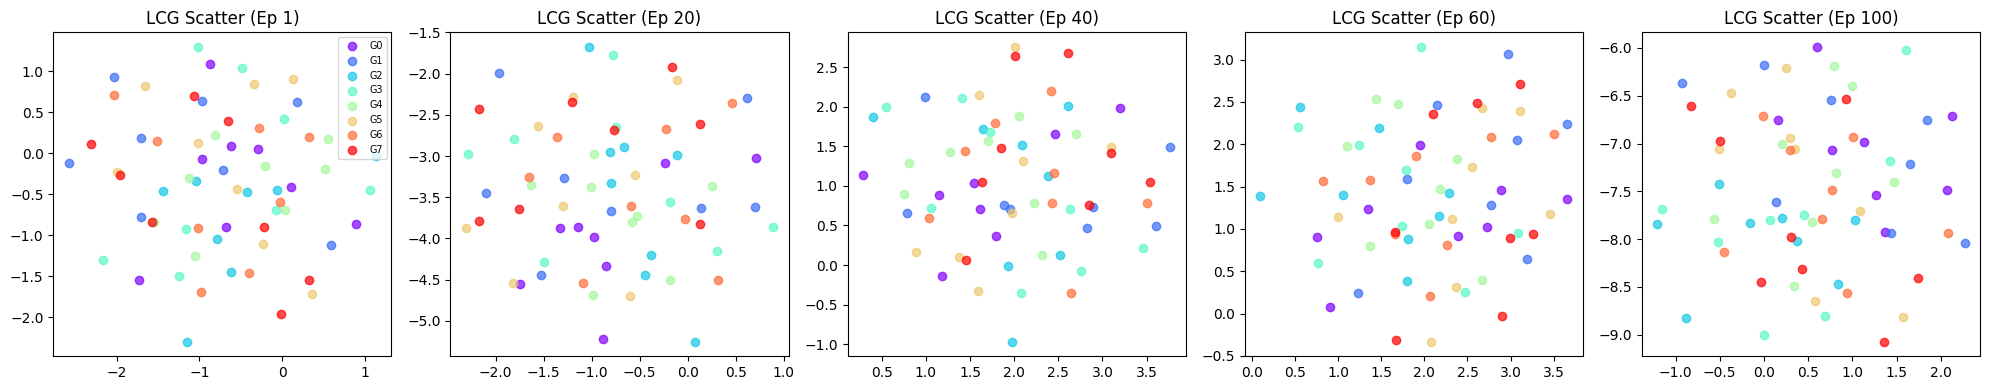

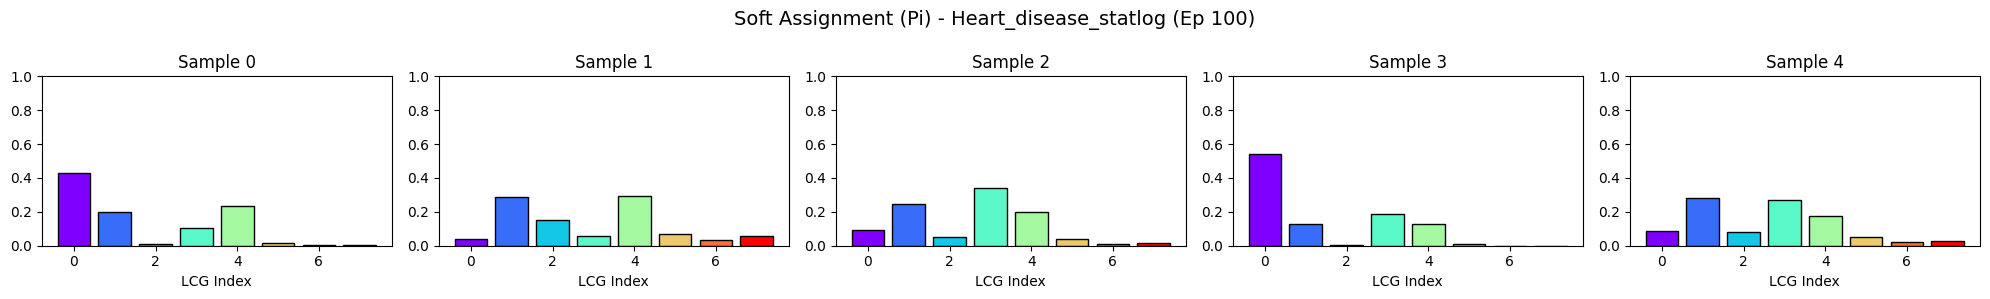

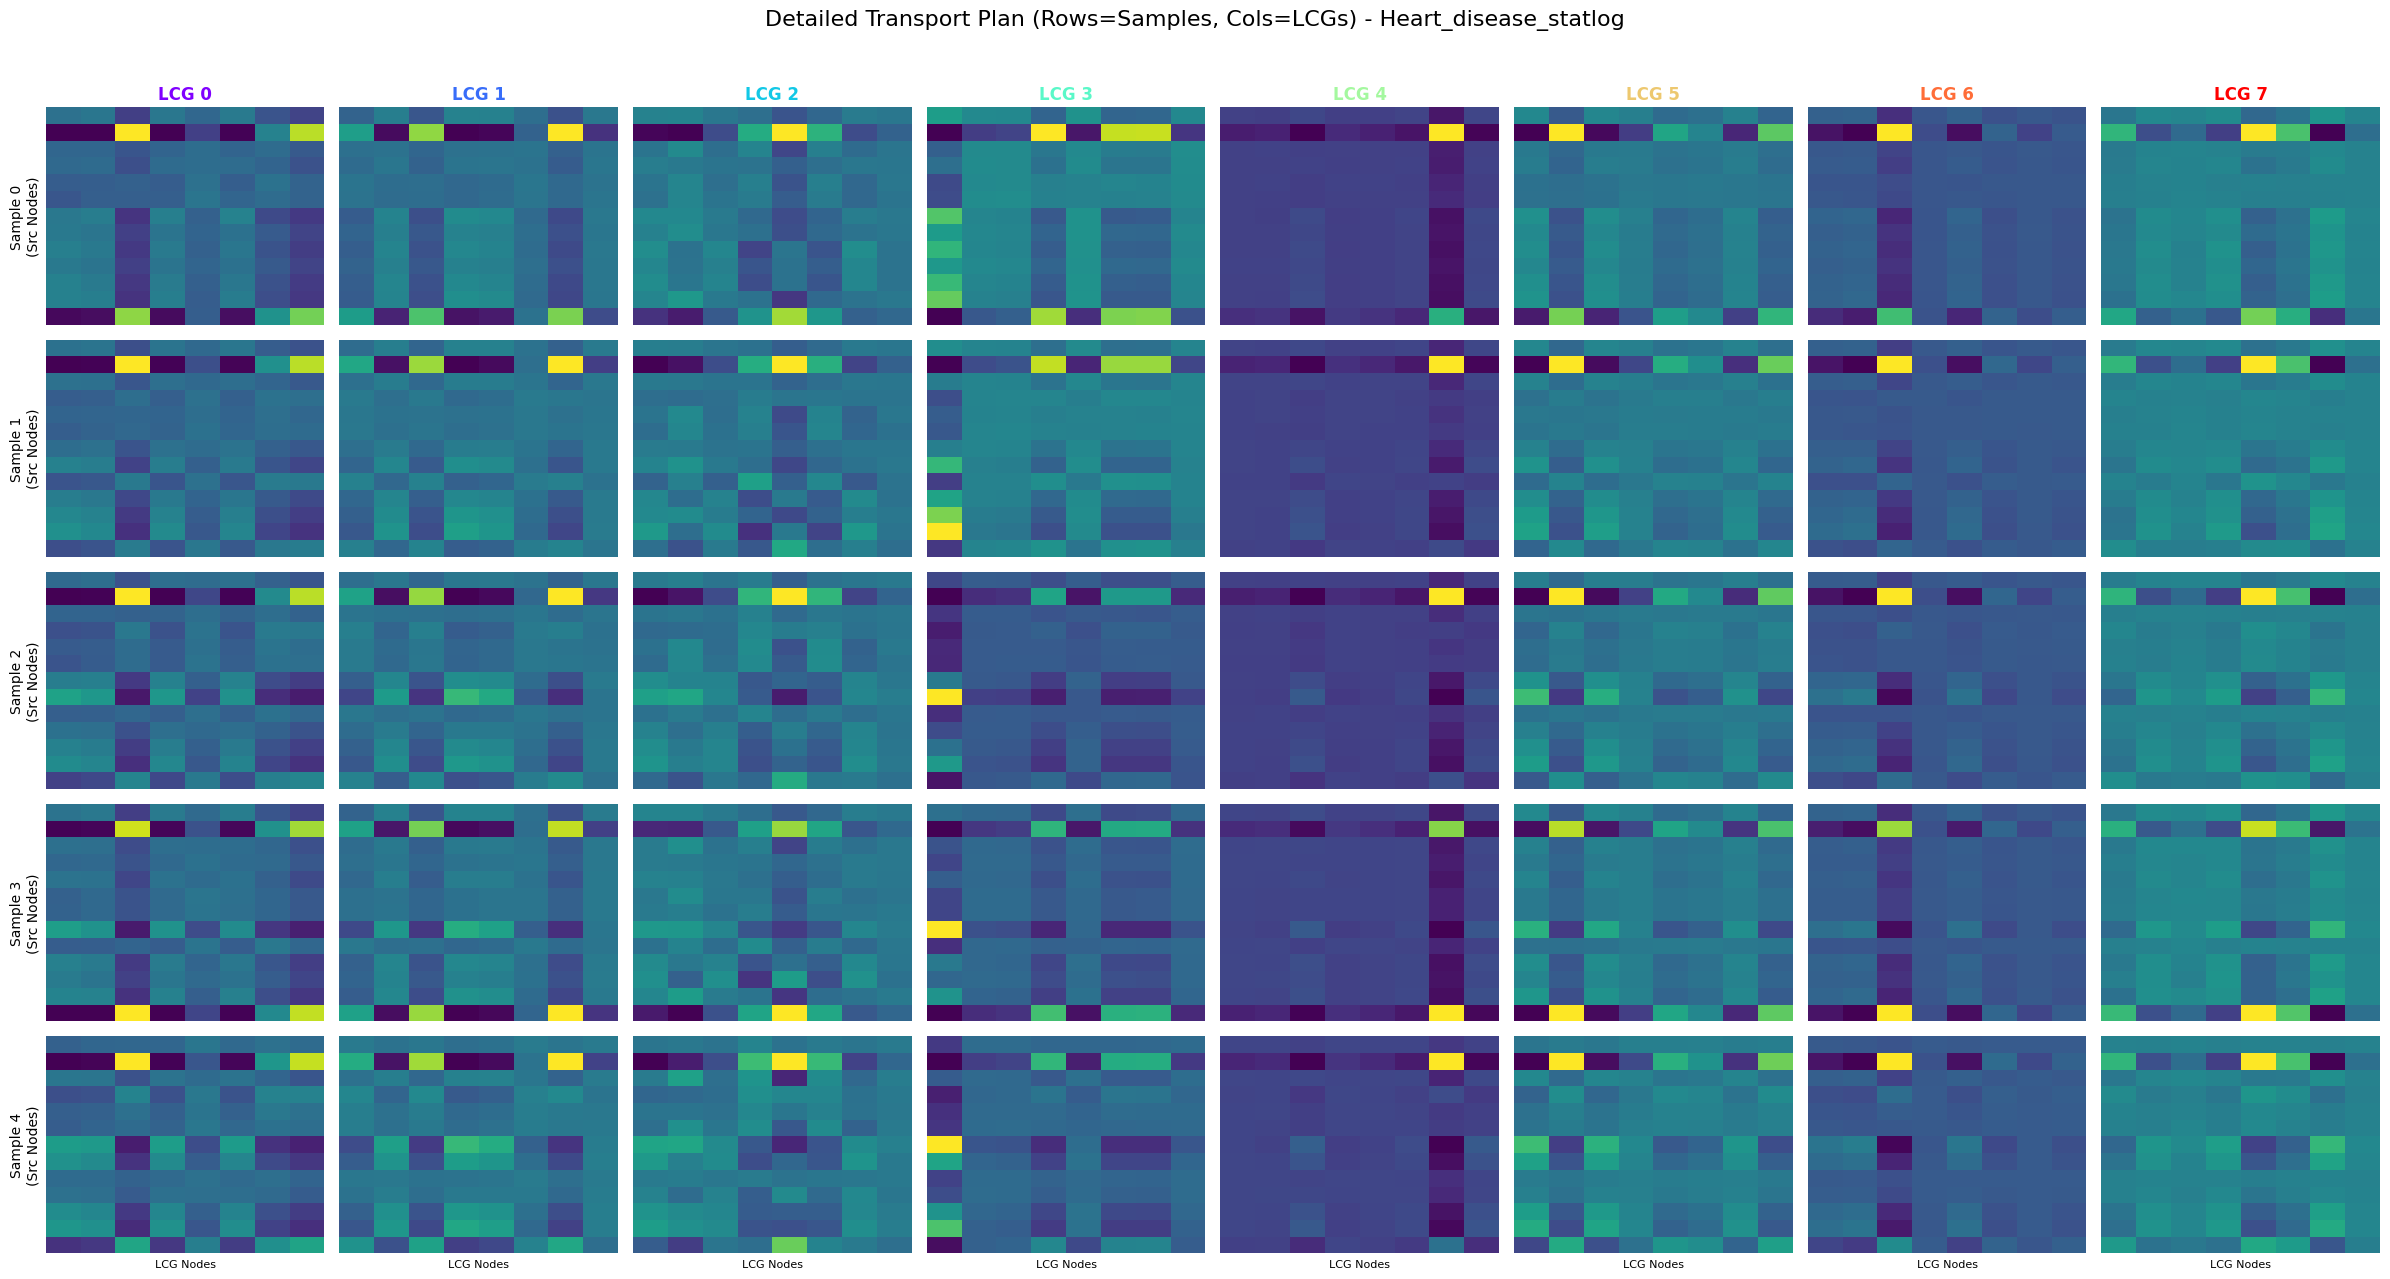

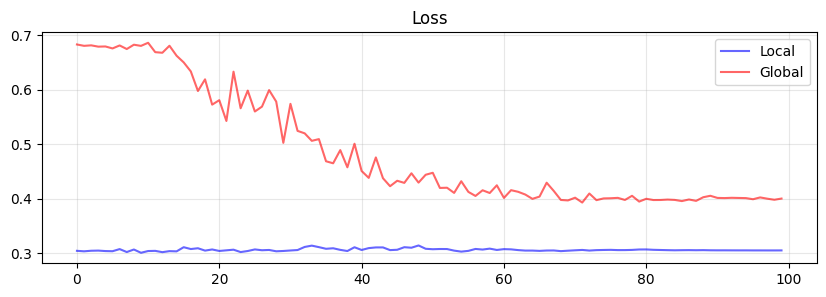

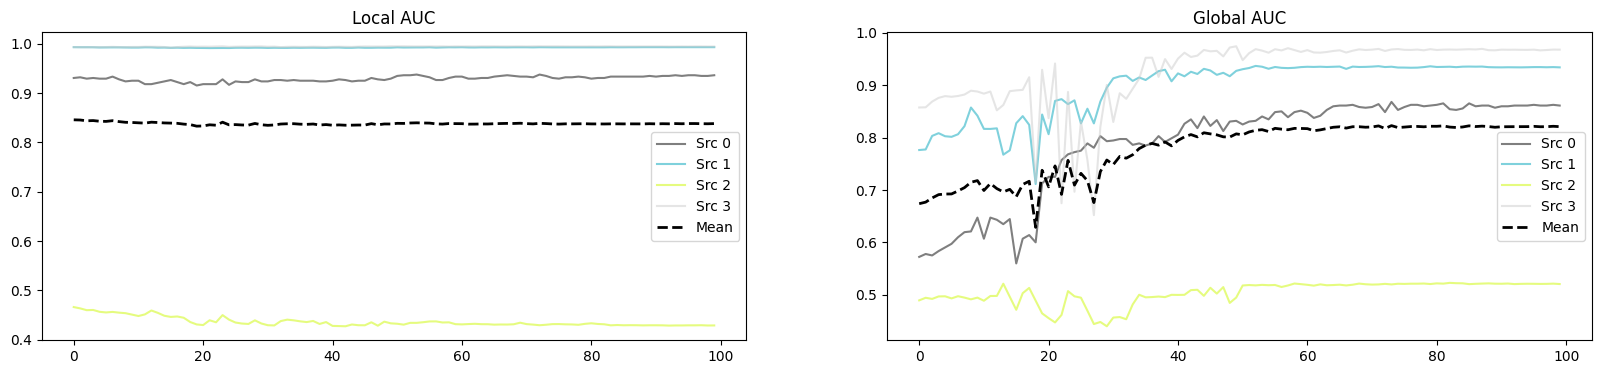

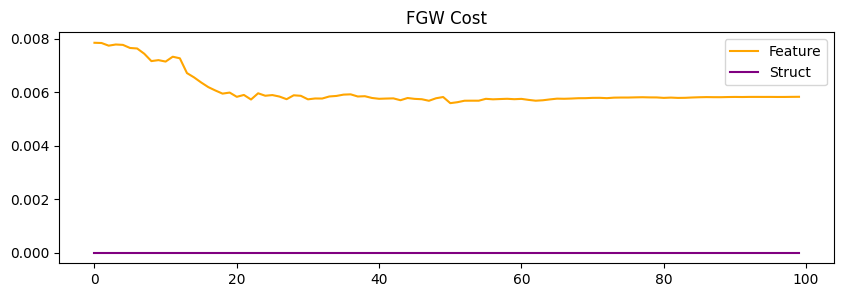

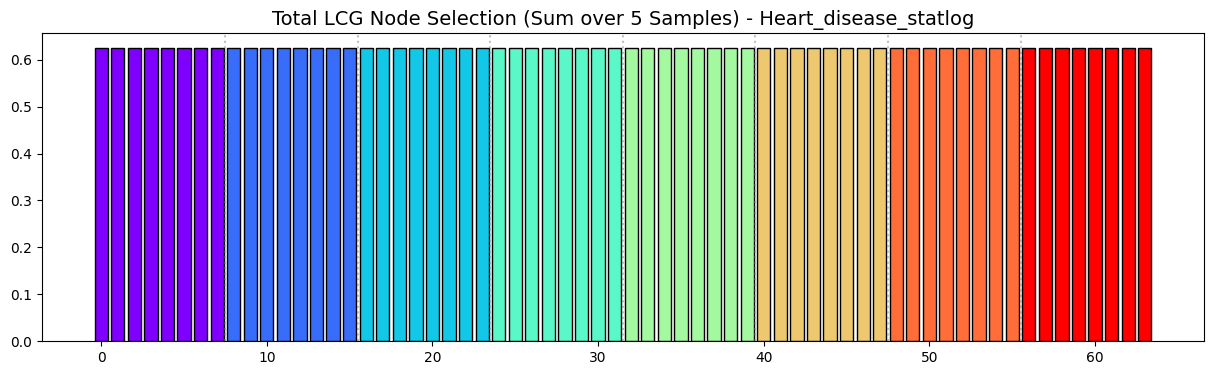

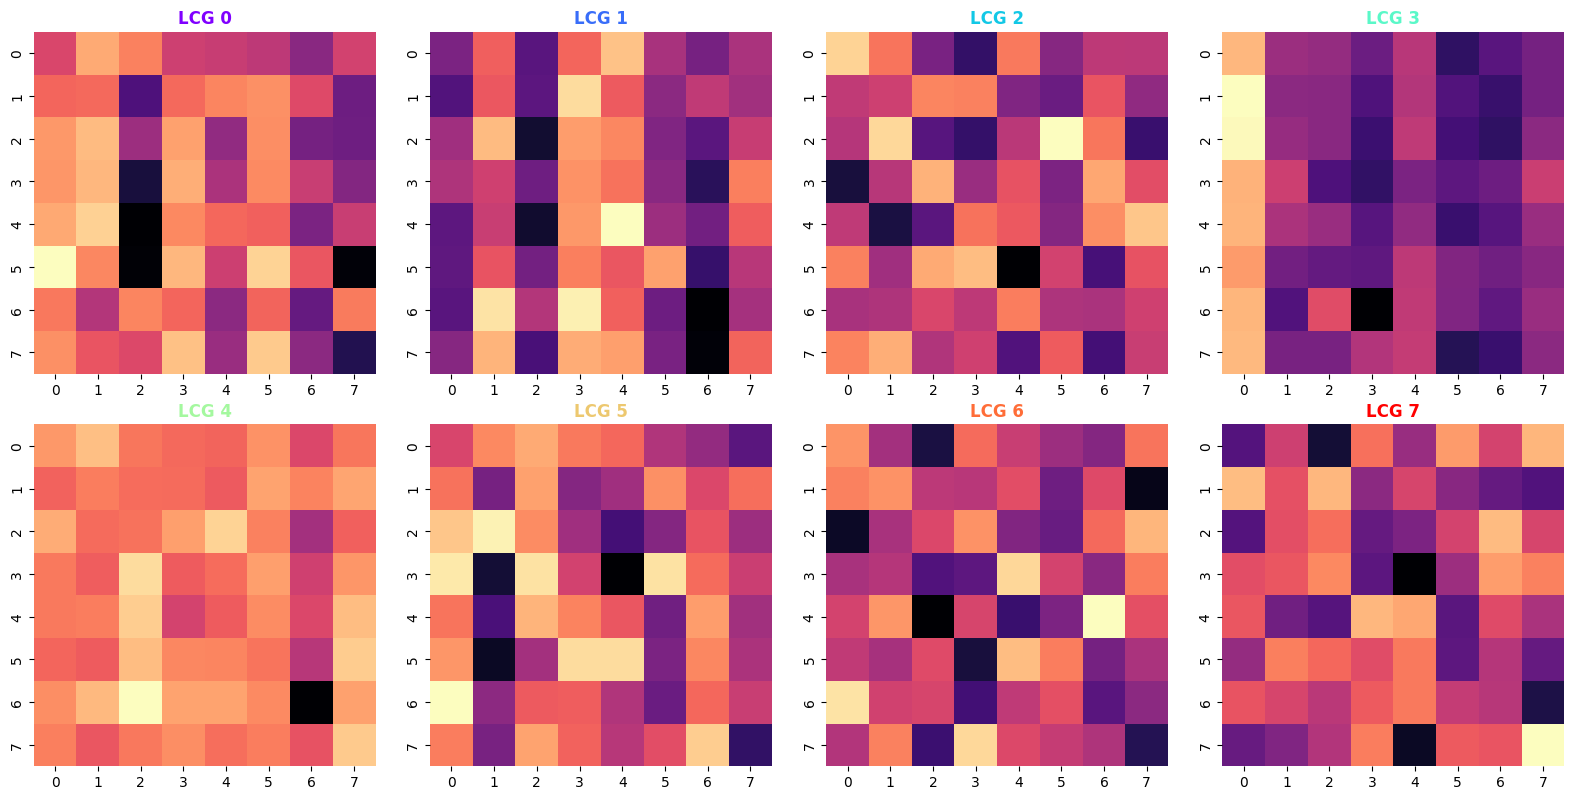

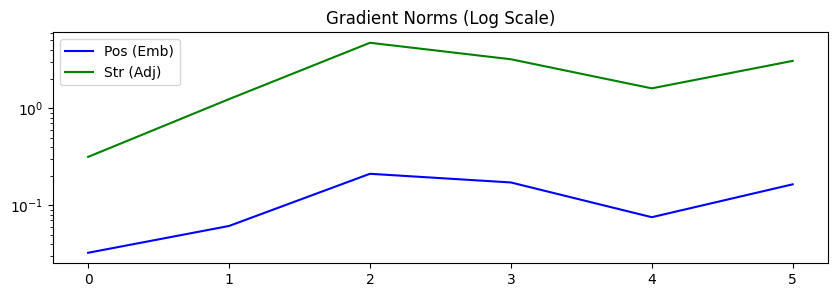

In [5]:
from types import MethodType

# =============================================================================
# 1. Argument & Model Loading
# =============================================================================
ckpt_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/Heart_disease_statlog+Cardiovascular_Disease_Dataset+heart_target_3+heart_target_4/Pre/ngraphs-8_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_fgw_alpha-1_vq_beta-0.3_kl_gamma-2.0_target_data-heart_description-graddetach5_joint_lrdown/42/best_vanilla.pt"

if not os.path.exists(ckpt_path):
    raise FileNotFoundError(f"Checkpoint not found: {ckpt_path}")

print(f">>> Loading Checkpoint from: {ckpt_path}")
ckpt = torch.load(ckpt_path, map_location=device)
args = ckpt['args']

# [Config Override]
args.use_lcg = True  # Phase 2 활성화
args.train_epochs = 100
args.source_lr = 0.0001
args.source_data = args.source_data if isinstance(args.source_data, (list, tuple)) else [args.source_data]

fix_seed(args.random_seed)

# 모델 초기화
model = Model(
    args, args.input_dim, args.hidden_dim, args.output_dim, args.dropout_rate, args.llm_model,
    experiment_id="viz_phase2", mode="Full"
).to(device)

sd = ckpt['model_state_dict']
model.load_state_dict(sd, strict=False)
print(">>> Model Loaded (Phase 2).")

# =============================================================================
# 2. [Patch] GraphQuantizer Hook (시각화용)
# =============================================================================
def patched_quantizer_forward(self, source_struct, source_feat, lcg_struct, lcg_feat, batch):
    B, N, D = source_feat.shape 
    M, K, _ = lcg_feat.shape 
    src_feat_exp = source_feat.unsqueeze(1).expand(B, M, N, D).reshape(B*M, N, D)
    src_str_exp = source_struct.unsqueeze(1).expand(B, M, N, N).reshape(B*M, N, N)
    lcg_feat_exp = lcg_feat.unsqueeze(0).expand(B, M, K, D).reshape(B*M, K, D)
    lcg_str_exp = lcg_struct.unsqueeze(0).expand(B, M, K, K).reshape(B*M, K, K)
    
    self.log_step += 1 
    
    dist_commit, plan_commit = self.compute_fgw(src_feat_exp, src_str_exp, lcg_feat_exp, lcg_str_exp)
    d_commit = dist_commit.reshape(B, M)
    pi = torch.softmax(-d_commit / self.soft_tau, dim = 1)

    # Hook
    self.last_pi = pi.detach()
    if plan_commit is not None:
        self.last_plan = plan_commit.detach().reshape(B, M, N, K)

    dist_codebook, _ = self.compute_fgw(src_feat_exp.detach(), src_str_exp.detach(), lcg_feat_exp, lcg_str_exp)
    d_codebook = dist_codebook.reshape(B, M)
    pi_detached = pi.detach() 
    loss_codebook = (pi_detached * d_codebook).sum(dim=1).mean() 
    loss_commitment = (pi_detached * d_commit).sum(dim=1).mean() 
    
    e_beta = getattr(self, 'entropy_beta', 0.0)
    entropy = -(pi * torch.log(pi + 1e-9)).sum(dim=1).mean()
    vq_loss = loss_codebook + self.vq_beta * loss_commitment - e_beta * entropy
    return lcg_feat, lcg_struct, pi, vq_loss

# 속성 추가 및 메서드 바인딩
if not hasattr(model.graph_quantizer, 'last_pi'): model.graph_quantizer.last_pi = None
if not hasattr(model.graph_quantizer, 'last_plan'): model.graph_quantizer.last_plan = None
model.graph_quantizer.forward = MethodType(patched_quantizer_forward, model.graph_quantizer)
print(">>> [Patch] GraphQuantizer hooked.")

# =============================================================================
# 3. Data & Optimizer Setup
# =============================================================================
sources = args.source_data
trains, vals, tests = [], [], []
print(f">>> Loading Sources: {sources}")

for name in sources:
    # [Safe Loading] Dict/Tuple 리턴 타입 모두 처리
    res = prepare_embedding_dataloaders(args, name)
    if isinstance(res, dict): tr, va, te = res['loaders']
    else: tr, va, te, nc = res
    trains.append(tr); vals.append(va); tests.append(te)

tr_step = make_step(trains, mode='random', seed=args.random_seed)
val_steps = [MultiSourceStepLoader([vals[i]], mode='round', seed=args.random_seed, src_idx=i) for i in range(len(vals))]

base_params = [p for n, p in model.named_parameters() if "latent_graph" not in n and "gnn_experts" not in n and p.requires_grad]
lcg_params = [p for n, p in model.named_parameters() if ("latent_graph" in n or "gnn_experts" in n) and p.requires_grad]

optimizer = optim.Adam([{'params': base_params, 'lr': args.source_lr * 0.1}, {'params': lcg_params, 'lr': args.source_lr * 0.2}], weight_decay=1e-5)
scheduler = make_warmup_cosine_epochs(optimizer, args.train_epochs, warmup_epochs=max(1, int(0.1*args.train_epochs)), min_lr_mult=0.01)

is_bin = (args.output_dim == 1) or (args.num_classes == 2)
criterion = nn.BCEWithLogitsLoss() if is_bin else nn.CrossEntropyLoss()

# =============================================================================
# 4. Training Loop
# =============================================================================
collector = VizCollector(args, sources, tr_step.loaders, device, save_interval=20)
print(f"\n>>> Start Joint Training (Phase 2) for {args.train_epochs} Epochs...")

for epoch in range(args.train_epochs):
    # Safe Train
    train_loss = binary_train(model, tr_step, criterion, optimizer, device) if is_bin else multi_train(model, tr_step, criterion, optimizer, device)
    if scheduler: scheduler.step()
    if hasattr(model, 'current_epoch'): model.current_epoch = epoch + 1

    # Eval
    l_aucs, g_aucs, l_loss_sum, g_loss_sum = [], [], 0.0, 0.0
    for vl in val_steps:
        res_g, res_l = binary_evaluate(model, vl, criterion, device) if is_bin else multi_evaluate(model, vl, criterion, device)
        l_loss_sum += res_l[0]; g_loss_sum += res_g[0]
        if is_bin:
            l_aucs.append(roc_auc_score(res_l[1], res_l[2]))
            g_aucs.append(roc_auc_score(res_g[1], res_g[2]))
        else:
            lb = label_binarize(res_l[1], classes=range(res_l[2].shape[1]))
            l_aucs.append(roc_auc_score(lb, res_l[2], multi_class='ovr', average='macro'))
            g_aucs.append(roc_auc_score(lb, res_g[2], multi_class='ovr', average='macro'))

    fgw_val = getattr(model, 'fgw_loss', torch.tensor(0.0)).item()
    collector.step(
        epoch, model,
        losses={'local': l_loss_sum/len(val_steps), 'global': g_loss_sum/len(val_steps)},
        aucs={'local_mean': np.mean(l_aucs), 'global_mean': np.mean(g_aucs), 'local_per_src': l_aucs, 'global_per_src': g_aucs},
        costs={'feat': fgw_val, 'struct': 0.0}
    )
    
    if (epoch + 1) % 10 == 0:
        print(f"[Ep {epoch+1:03d}] Loss(L/G): {l_loss_sum/len(val_steps):.4f}/{g_loss_sum/len(val_steps):.4f} | AUC(L/G): {np.mean(l_aucs):.4f}/{np.mean(g_aucs):.4f} | FGW: {fgw_val:.4f}")

print("\n>>> Training Finished. Plotting...")
plot_training_results(collector.history, n_graphs=args.n_graphs, n_nodes=args.n_nodes)